# 1. SVM modell

## Modell relevanciája

A Support Vector Machine, röviden SVM, egy felügyelt tanulási algoritmus, amely klasszifikációs feladatokra is alkalmazható. A prediktív karbantartási probléma bináris osztályozási feladatként kezelhető, ezért az SVM alkalmas lehet annak előrejelzésére, hogy egy adott gépállapot meghibásodáshoz vezet-e vagy sem.

Az SVM különösen azért releváns ebben a feladatban, mert nemcsak egyszerű lineáris döntési határt tud tanulni, hanem kernel segítségével nemlineáris mintázatokat is képes kezelni. Ez fontos lehet prediktív karbantartási adatoknál, ahol a meghibásodás sokszor több változó együttes, nemlineáris kapcsolatából következik.

## Elméleti háttér

Az SVM célja, hogy olyan döntési határt találjon az osztályok között, amely a lehető legnagyobb margint biztosítja. A margin a döntési határ és a hozzá legközelebb eső tanítópontok közötti távolság. A döntési határhoz legközelebbi pontokat support vectoroknak, vagyis támaszvektoroknak nevezzük, mert ezek határozzák meg leginkább a modell döntési határát.

A gyakorlatban általában soft margin SVM-et használunk, amely megengedi, hogy néhány adatpont a marginon belülre vagy akár rossz oldalra kerüljön. Ez azért hasznos, mert valós adatoknál gyakori a zaj, az outlier vagy az osztályok részleges átfedése.

Az SVM egyik fontos előnye a kernel trükk. Kernel segítségével a modell képes az adatokat implicit módon magasabb dimenziós térben kezelni, ahol a nemlineárisan szeparálható adatok is lineárisan elválaszthatóvá válhatnak. Ebben a modellben RBF kernelt használunk, mert ez rugalmas, nemlineáris döntési határt tud tanulni.

Mivel az SVM érzékeny a változók skálájára, a folytonos numerikus változókat standardizáljuk.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

## 2. Train és test csv beolvasás

In [2]:
train_df = pd.read_csv("../../DataCleaning/train.csv")
test_df = pd.read_csv("../../DataCleaning/test.csv")

## 3. X és y szétválasztása

- `X_train`: tanító magyarázó változók
- `y_train`: tanító célváltozó
- `X_test`: teszt magyarázó változók
- `y_test`: teszt célváltozó

In [3]:
target_col = "target"

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 8)
y_train shape: (8000,)
X_test shape: (2000, 8)
y_test shape: (2000,)


## 4. Osztályeloszlás ellenőrzése

In [4]:
def show_class_distribution(y, dataset_name):
    counts = y.value_counts().sort_index()
    ratios = y.value_counts(normalize = True).sort_index()*100

    dist_df = pd.DataFrame({
        "Count": counts,
        "Ratio (%)": ratios.round(2)
    })

    display(dist_df)

    return dist_df

train_dist = show_class_distribution(y_train, "Train")
test_dist = show_class_distribution(y_test, "Test")

,Count,Ratio (%)
target,,
0,7729,96.61
1,271,3.39


,Count,Ratio (%)
target,,
0,1932,96.6
1,68,3.4


## 5. SVM-specifikus előfeldolgozás meghatározása

Az SVM érzékeny a változók skálájára, mivel a modell a megfigyelések közötti távolságok, a döntési határ és a margin alapján tanul. Emiatt a folytonos numerikus változókat standardizáljuk.

A bináris / dummy változókat változatlanul továbbengedjük, mivel ezek már 0/1 formában szerepelnek az adathalmazban.

A pipeline végén egy Support Vector Classifier modellt alkalmazunk. Az SVM célja, hogy olyan döntési határt találjon, amely a lehető legnagyobb margót biztosítja az osztályok között. A soft margin SVM néhány hibás vagy bizonytalan osztályozást is megenged, ami javíthatja az általánosító képességet. 

In [5]:
numeric_columns = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
binary_features = ["type_L", "type_M"]

numeric_features = [
    col for col in numeric_columns
    if col not in binary_features
]
print("Numerikus változók száma:", len(numeric_features))
print(numeric_features)

selected_features = numeric_features + binary_features
print("Összes X_train oszlop:", X_train.shape[1])
print("Pipeline-ba bevont oszlopok:", len(selected_features))

Numerikus változók száma: 6
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'temperature_difference_k']
Összes X_train oszlop: 8
Pipeline-ba bevont oszlopok: 8


## 6. Pipeline létrehozása

Az SVM modellhez pipeline-t hozunk létre, amely az előfeldolgozási lépéseket és a modellt egy közös folyamatba szervezi.

A pipeline-ban:

- a folytonos numerikus változókat `StandardScaler` segítségével standardizáljuk,
- a bináris / dummy változókat változatlanul továbbengedjük,
- majd egy Support Vector Classifier modellt tanítunk.

Az SVM esetében a skálázás kiemelten fontos, mert a modell a pontok közötti távolságok, a margin és a döntési határ alapján működik. Ha a változók eltérő skálán vannak, akkor a nagyobb nagyságrendű változók túlzottan befolyásolhatják a döntési határt.

A modellben RBF kernelt használunk, mert ez nemlineáris döntési határ tanulását is lehetővé teszi. A `probability=True` beállítást azért alkalmazzuk, hogy a modell valószínűségi kimenetet is adjon, amely később ROC-AUC számításhoz és threshold vizsgálathoz is használható.

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("bin", "passthrough", binary_features)
    ],
    remainder="drop"
)

svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

svm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 7. Keresztvalidáció beállítása

Az SVM modell értékeléséhez 5-fold stratifikált keresztvalidációt alkalmazunk.

A keresztvalidáció célja, hogy stabilabb képet kapjunk a modell teljesítményéről, mintha csak egyetlen tanító-validációs bontást használnánk. A modell több körben tanul és validálódik, minden körben más validációs részhalmazzal.

A `StratifiedKFold` használata azért indokolt, mert a célváltozó osztályarányait minden foldban igyekszik megtartani. Ez különösen fontos prediktív karbantartási feladat esetén, ahol a meghibásodásos esetek jellemzően ritkábban fordulnak elő.

A keresztvalidációt kizárólag a tanító adaton végezzük. A tesztadatot csak a végső modellértékelés során használjuk.

In [7]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## 8. SVM modell tanítása hiperparaméter-kereséssel

Az SVM modell teljesítménye jelentősen függhet a választott hiperparaméterektől, ezért ennél a modellnél hiperparaméter-keresést alkalmazunk.

A hiperparaméterek olyan modellbeállítások, amelyeket a modell nem az adatokból tanul meg automatikusan, hanem a tanítás előtt kell megadnunk. Ilyen például az SVM esetében a kernel típusa, a `C` paraméter, a `gamma` érték vagy az osztálysúlyozás.

A hiperparaméter-keresés célja, hogy ne egyetlen előre kiválasztott SVM-beállítást használjunk, hanem több lehetséges beállítást is kipróbáljunk. Ezeket a beállításokat keresztvalidáció segítségével értékeljük, majd kiválasztjuk azt a konfigurációt, amely a legjobb átlagos teljesítményt adja.

Ebben a notebookban a `GridSearchCV` módszert használjuk. Ez a megadott hiperparaméter-kombinációkat végigpróbálja, és mindegyiket 5-fold stratifikált keresztvalidációval értékeli. A legjobb modellt az átlagos validációs F1-score alapján választjuk ki.

Az F1-score használata azért indokolt, mert prediktív karbantartási feladatban gyakran osztályegyensúlytalanság figyelhető meg. Ilyenkor az accuracy önmagában félrevezető lehet, míg az F1-score egyszerre veszi figyelembe a precision és a recall értékeket.

A vizsgált fő SVM hiperparaméterek:

- `kernel`: meghatározza, hogy milyen típusú döntési határt tud tanulni a modell.  
  - A `linear` kernel lineáris döntési határt tanul.
  - Az `rbf` kernel nemlineáris döntési határt is képes tanulni.

- `C`: azt szabályozza, hogy a modell mennyire büntesse a hibás osztályozásokat.
  - Nagyobb `C` érték esetén a modell szigorúbb, kevesebb hibát enged meg a tanító adaton.
  - Kisebb `C` érték esetén a modell megengedőbb, szélesebb margint engedhet, ami jobb általánosítást eredményezhet.

- `gamma`: az RBF kernel érzékenységét szabályozza.
  - Kis `gamma` érték esetén a modell simább, általánosabb döntési határt tanul.
  - Nagy `gamma` érték esetén a modell lokálisabb mintázatokra is érzékenyebb, de nőhet a túltanulás kockázata.

- `class_weight`: az osztályegyensúlytalanság kezelésére szolgál.
  - `None` esetén a modell nem alkalmaz külön osztálysúlyozást.
  - `"balanced"` esetén a ritkább osztály nagyobb súlyt kap, így a modell jobban figyelhet a meghibásodásos esetek felismerésére.

A hiperparaméter-keresés után a legjobb SVM beállítást használjuk a végső teszthalmazon történő értékeléshez.

In [8]:
from sklearn.model_selection import GridSearchCV

svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__class_weight": [None, "balanced"]
    }
]

svm_grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

svm_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__kernel': ['linear']}, {'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__gamma': ['scale', 0.01, ...], 'model__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... sh

## 9a. Tanítás és keresztvalidációs eredmények értelmezése

Az SVM modell tanítása során hiperparaméter-keresést alkalmaztunk `GridSearchCV` segítségével. Ez azt jelenti, hogy több különböző SVM-beállítást próbáltunk ki, majd ezeket 5-fold stratifikált keresztvalidációval értékeltük.

A keresztvalidáció célja az volt, hogy ne egyetlen előre kiválasztott modellbeállítást használjunk, hanem az adatok alapján válasszuk ki a legjobban teljesítő konfigurációt.

A modellválasztás alapja az átlagos validációs F1-score volt. Az F1-score azért megfelelő mutató ebben az esetben, mert egyszerre veszi figyelembe a precision és recall értékeket. Ez különösen fontos prediktív karbantartási feladatban, ahol az osztályegyensúlytalanság miatt az accuracy önmagában félrevezető lehet.

Ebben a lépésben megvizsgáljuk:

- melyik SVM konfiguráció teljesített a legjobban,
- milyen kernel, C, gamma és class_weight beállításokat választott a GridSearchCV,
- mekkora volt a legjobb keresztvalidációs F1-score,
- valamint hogy a train és validation eredmények alapján látható-e túltanulásra utaló jel.

In [11]:
print("Legjobb SVM paraméterek:")
print(svm_grid_search.best_params_)

print("\nLegjobb átlagos validációs F1-score:")
print(round(svm_grid_search.best_score_, 4))

best_svm_model = svm_grid_search.best_estimator_

svm_grid_results_df = pd.DataFrame(svm_grid_search.cv_results_)

cols_to_keep = [
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "param_model__kernel",
    "param_model__C",
    "param_model__gamma",
    "param_model__class_weight",
    "rank_test_score"
]

# Csak azok az oszlopok maradjanak, amelyek ténylegesen léteznek
cols_to_keep = [col for col in cols_to_keep if col in svm_grid_results_df.columns]

svm_grid_results_selected = svm_grid_results_df[cols_to_keep].copy()

svm_grid_results_selected = svm_grid_results_selected.rename(columns={
    "mean_test_score": "Validation F1 mean",
    "std_test_score": "Validation F1 std",
    "mean_train_score": "Train F1 mean",
    "std_train_score": "Train F1 std",
    "param_model__kernel": "Kernel",
    "param_model__C": "C",
    "param_model__gamma": "Gamma",
    "param_model__class_weight": "Class weight",
    "rank_test_score": "Rank"
})

svm_grid_results_selected = svm_grid_results_selected.sort_values(
    by="Rank",
    ascending=True
)

display(svm_grid_results_selected.head(30))

Legjobb SVM paraméterek:
{'model__C': 10, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Legjobb átlagos validációs F1-score:
0.6687


,Validation F1 mean,Validation F1 std,Train F1 mean,Train F1 std,Kernel,C,Gamma,Class weight,Rank
22,0.668679,0.048188,0.789810,0.015577,rbf,10.0,scale,NaN,1
24,0.603226,0.043501,0.717386,0.016685,rbf,10.0,0.1,NaN,2
25,0.596044,0.039159,0.956425,0.004995,rbf,10.0,1,NaN,3
29,0.568590,0.016038,0.939441,0.009207,rbf,10.0,1,balanced,4
26,0.505561,0.029983,0.597890,0.009820,rbf,10.0,scale,balanced,5
21,0.495575,0.014761,0.742098,0.009715,rbf,1.0,1,balanced,6
28,0.487236,0.026359,0.552795,0.008118,rbf,10.0,0.1,balanced,7
14,0.446636,0.070677,0.521644,0.023180,rbf,1.0,scale,NaN,8
13,0.431091,0.033542,0.535265,0.014725,rbf,0.1,1,balanced,9
18,0.428851,0.027207,0.485708,0.005031,rbf,1.0,scale,balanced,10


### 9b. A legjobb SVM konfiguráció értelmezése

A hiperparaméter-keresés eredményei alapján a legjobb SVM konfiguráció az **RBF kernelű modell** lett, `C=10`, `gamma="scale"` és `class_weight=None` beállításokkal. Ez a konfiguráció érte el a legmagasabb átlagos validációs F1-score értéket, amely **0.6687** volt.

A választás azért indokolt, mert a modellkiválasztás fő szempontja az F1-score volt. Az F1-score egyszerre veszi figyelembe a precision és recall értékeket, ezért osztályegyensúlytalanság esetén alkalmasabb mutató, mint az accuracy önmagában. Prediktív karbantartási feladatban ez különösen fontos, mert nemcsak az számít, hogy a modell összességében hány esetet sorol be helyesen, hanem az is, hogy a meghibásodásos eseteket milyen arányban képes felismerni.

Az, hogy a legjobb modell **RBF kernelt** használ, arra utal, hogy az adatokban valószínűleg nemlineáris mintázatok is jelen vannak. Az RBF kernel lehetővé teszi, hogy az SVM ne csak egy lineáris döntési határt tanuljon, hanem rugalmasabb, nemlineáris szeparációt is alkalmazzon.

A `C=10` érték azt jelzi, hogy a legjobb modell viszonylag szigorúbb beállítással működött jól. Ez azt jelenti, hogy a modell erősebben büntette a hibás osztályozásokat, és kevésbé engedte meg, hogy a tanítópontok rossz oldalra kerüljenek.

A `gamma="scale"` beállítás az sklearn alapértelmezett, adatfüggő skálázását használja az RBF kernelhez. Ez a beállítás a validációs eredmények alapján jobb általánosító képességet adott, mint a kézzel megadott gamma értékek.

A `class_weight=None` eredménye azt mutatja, hogy ebben a hiperparaméter-keresésben az automatikus osztálysúlyozás nem javította a validációs F1-score-t. Ez nem jelenti azt, hogy az osztályegyensúlytalanság nem fontos, hanem azt, hogy az adott SVM konfiguráció mellett a súlyozás nélküli modell adott jobb precision-recall egyensúlyt.

A train és validation F1-score összehasonlítása alapján a legjobb modellnél a train F1-score magasabb volt, mint a validációs F1-score. Ez enyhe túltanulásra utalhat, azonban a validációs F1-score továbbra is a legmagasabb volt a vizsgált konfigurációk között. Emiatt ezt a modellt választjuk ki a végső, független teszthalmazon történő értékeléshez.

## 10. Végső SVM modell kiválasztása és tesztelése a test adaton

A hiperparaméter-keresés után a GridSearchCV kiválasztotta a legjobb SVM konfigurációt. A kiválasztás alapja az 5-fold stratifikált keresztvalidáció során elért átlagos validációs F1-score volt.

A legjobb konfiguráció az RBF kernelű SVM modell lett, `C=10`, `gamma="scale"` és `class_weight=None` beállításokkal. Ezt a modellt használjuk végső SVM modellként.

Fontos, hogy a végső modell kiválasztása kizárólag a tanító adaton belüli keresztvalidáció alapján történt. A `test.csv` adathalmazt eddig nem használtuk sem a tanítás, sem a hiperparaméter-választás során, ezért alkalmas a modell független értékelésére.

A következő lépésben a kiválasztott legjobb SVM modellt alkalmazzuk a teszthalmazon, majd kiszámítjuk az osztálypredikciókat és a pozitív osztályhoz, vagyis a meghibásodáshoz tartozó becsült valószínűségeket.

In [15]:
final_svm_model = svm_grid_search.best_estimator_

print("Végső SVM modell:")
print(final_svm_model)

print("\nLegjobb paraméterek:")
print(svm_grid_search.best_params_)

y_test_pred_svm = final_svm_model.predict(X_test)
y_test_proba_svm = final_svm_model.predict_proba(X_test)[:, 1]



Végső SVM modell:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['air_temperature_k',
                                                   'process_temperature_k',
                                                   'rotational_speed_rpm',
                                                   'torque_nm', 'tool_wear_min',
                                                   'temperature_difference_k']),
                                                 ('bin', 'passthrough',
                                                  ['type_L', 'type_M'])])),
                ('model', SVC(C=10, probability=True, random_state=42))])

Legjobb paraméterek:
{'model__C': 10, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


## 11. Confusion matrix készítése

A confusion matrix segítségével megvizsgáljuk, hogy az SVM modell a teszthalmazon hány esetet sorolt be helyesen vagy hibásan.

A mátrix elemei:

- **TN:** valódi negatív eset, amelyet a modell negatívnak jelzett,
- **FP:** valódi negatív eset, amelyet a modell tévesen pozitívnak jelzett,
- **FN:** valódi pozitív eset, amelyet a modell tévesen negatívnak jelzett,
- **TP:** valódi pozitív eset, amelyet a modell pozitívnak jelzett.

Prediktív karbantartási feladatnál különösen fontos az FN érték, mert ez azt jelenti, hogy a modell nem ismert fel egy valódi meghibásodásos esetet.

In [17]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_test_pred_svm)

tn_svm, fp_svm, fn_svm, tp_svm = cm_svm.ravel()

confusion_matrix_svm_df = pd.DataFrame(
    cm_svm,
    index=["Valós 0 - nincs meghibásodás", "Valós 1 - meghibásodás"],
    columns=["Prediktált 0 - nincs meghibásodás", "Prediktált 1 - meghibásodás"]
)

display(confusion_matrix_svm_df)


,Prediktált 0 - nincs meghibásodás,Prediktált 1 - meghibásodás
Valós 0 - nincs meghibásodás,1924,8
Valós 1 - meghibásodás,26,42


## 12. Teljesítménymutatók számítása

Az SVM modell teljesítményét több mutató alapján értékeljük.

Az accuracy azt mutatja meg, hogy az összes eset mekkora részét sorolta be helyesen a modell. Osztályegyensúlytalanság esetén azonban az accuracy önmagában félrevezető lehet, ezért további mutatókat is vizsgálunk.

A számított mutatók:

- **Accuracy:** az összes helyes predikció aránya,
- **Precision:** a pozitívnak jelzett esetek közül mennyi volt valóban pozitív,
- **Recall / TPR:** a valódi pozitív esetek közül mennyit ismert fel a modell,
- **Specificity / TNR:** a valódi negatív esetek közül mennyit ismert fel helyesen a modell,
- **FPR:** a valódi negatív esetek közül mennyit jelzett tévesen pozitívnak,
- **F1-score:** a precision és recall harmonikus átlaga,
- **ROC-AUC:** a modell általános osztályszétválasztó képessége.

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy_svm = accuracy_score(y_test, y_test_pred_svm)
precision_svm = precision_score(y_test, y_test_pred_svm, zero_division=0)
recall_svm = recall_score(y_test, y_test_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_test_pred_svm, zero_division=0)

specificity_svm = tn_svm / (tn_svm + fp_svm) if (tn_svm + fp_svm) != 0 else 0
fpr_svm = fp_svm / (fp_svm + tn_svm) if (fp_svm + tn_svm) != 0 else 0

roc_auc_svm = roc_auc_score(y_test, y_test_proba_svm)

svm_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall / TPR",
        "Specificity / TNR",
        "FPR",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_svm,
        precision_svm,
        recall_svm,
        specificity_svm,
        fpr_svm,
        f1_svm,
        roc_auc_svm
    ]
})

svm_metrics_df["Value"] = svm_metrics_df["Value"].round(4)

display(svm_metrics_df)


,Metric,Value
0,Accuracy,0.9830
1,Precision,0.8400
2,Recall / TPR,0.6176
3,Specificity / TNR,0.9959
4,FPR,0.0041
5,F1-score,0.7119
6,ROC-AUC,0.9734


## 13. ROC görbe és AUC

A ROC görbe a True Positive Rate és a False Positive Rate kapcsolatát mutatja különböző döntési küszöbök mellett.

A True Positive Rate megegyezik a recall értékkel, vagyis azt mutatja meg, hogy a modell a valódi pozitív esetek mekkora részét ismerte fel helyesen.

A False Positive Rate azt mutatja meg, hogy a modell a valódi negatív esetek mekkora részét jelölte tévesen pozitívnak.

Az AUC érték a modell általános osztályszétválasztó képességét foglalja össze. Minél közelebb van az AUC érték 1-hez, annál jobb a modell szeparációs képessége.

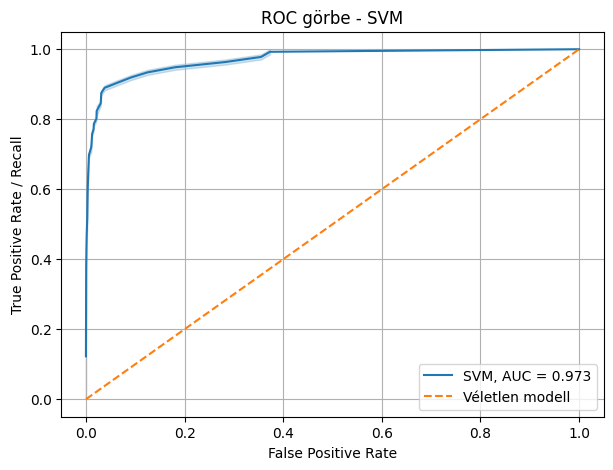

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns

fpr_values_svm, tpr_values_svm, thresholds_svm = roc_curve(y_test, y_test_proba_svm)
roc_auc_svm = roc_auc_score(y_test, y_test_proba_svm)

roc_svm_df = pd.DataFrame({
    "False Positive Rate": fpr_values_svm,
    "True Positive Rate": tpr_values_svm,
    "Threshold": thresholds_svm
})

plt.figure(figsize=(7, 5))

sns.lineplot(
    data=roc_svm_df,
    x="False Positive Rate",
    y="True Positive Rate",
    label=f"SVM, AUC = {roc_auc_svm:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Véletlen modell")

plt.title("ROC görbe - SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.grid(True)
plt.show()

### 14. ROC görbe és teszteredmények értékelése

Az SVM modell a teszthalmazon nagyon erős teljesítményt mutatott. Az accuracy értéke **0.9830**, ami azt jelzi, hogy a modell az összes teszteset nagy részét helyesen osztályozta. Mivel azonban a prediktív karbantartási feladatban osztályegyensúlytalanság is jelen lehet, az accuracy önmagában nem elegendő a modell értékeléséhez.

A precision értéke **0.8400**, vagyis amikor a modell meghibásodást jelzett, akkor az esetek 84%-ában valóban meghibásodás történt. Ez azt mutatja, hogy a modell kevés téves pozitív riasztást adott, tehát a pozitív jelzései viszonylag megbízhatóak.

A recall értéke **0.6176**, ami azt jelenti, hogy a modell a valódi meghibásodásos esetek körülbelül 62%-át felismerte. Prediktív karbantartási szempontból ez fontos eredmény, mert a modell már nemcsak a nem hibás eseteket azonosítja jól, hanem a tényleges meghibásodások jelentős részét is képes felismerni.

A specificity értéke **0.9959**, az FPR pedig **0.0041**, ami azt mutatja, hogy a modell a normál, nem meghibásodásos eseteket szinte teljesen pontosan felismerte, és csak nagyon kevés esetben adott téves pozitív riasztást.

Az F1-score értéke **0.7119**, ami jó egyensúlyt jelez a precision és recall között. Ez különösen fontos ennél a feladatnál, mert nemcsak az számít, hogy a modell pontosan jelezzen hibát, hanem az is, hogy a valódi meghibásodások minél nagyobb részét felismerje.

A ROC-AUC értéke **0.9734**, ami kiváló osztályszétválasztó képességre utal. Ez azt jelenti, hogy az SVM modell nagyon jól képes elkülöníteni a meghibásodásos és nem meghibásodásos eseteket a becsült valószínűségek alapján.

Összességében az SVM modell erős eredményt adott. A magas precision, a jó recall, az erős F1-score és a kiemelkedően magas ROC-AUC alapján a modell alkalmasnak tekinthető a prediktív karbantartási feladat megoldására. A következő lépésben opcionálisan megvizsgálható a döntési küszöb módosítása, de az alapértelmezett beállítások mellett kapott eredmény már önmagában is jó teljesítményt mutat.

## 15. Döntési küszöb módosításának vizsgálata

Az SVM modell `probability=True` beállítással készült, ezért a modell nemcsak osztálycímkét, hanem a pozitív, vagyis meghibásodásos osztályhoz tartozó becsült valószínűséget is visszaadja.

Ez lehetővé teszi, hogy az alapértelmezett döntési küszöb mellett más threshold értékeket is kipróbáljunk.

Az alapértelmezett 0.5-ös küszöb azt jelenti, hogy a modell akkor jelez meghibásodást, ha a becsült meghibásodási valószínűség legalább 50%.

Prediktív karbantartási feladatban a döntési küszöb módosítása azért lehet hasznos, mert a precision és recall között kompromisszum van:

- alacsonyabb küszöb esetén a modell több esetet jelöl meghibásodásként, így nőhet a recall,
- ugyanakkor több téves pozitív jelzés is keletkezhet, így csökkenhet a precision,
- magasabb küszöb esetén kevesebb téves pozitív jelzés várható, de több valódi meghibásodás maradhat felismeretlenül.

Ebben a lépésben több döntési küszöböt is kipróbálunk, majd táblázatban és vonaldiagramon hasonlítjuk össze az eredményeket.

,Threshold,Accuracy,Precision,Recall / TPR,Specificity / TNR,FPR,F1-score,ROC-AUC,TP,FP,FN,TN
0,0.50,0.9825,0.8235,0.6176,0.9953,0.0047,0.7059,0.9734,42,9,26,1923
1,0.45,0.9835,0.8302,0.6471,0.9953,0.0047,0.7273,0.9734,44,9,24,1923
2,0.40,0.9835,0.8070,0.6765,0.9943,0.0057,0.7360,0.9734,46,11,22,1921
3,0.35,0.9840,0.8000,0.7059,0.9938,0.0062,0.7500,0.9734,48,12,20,1920
4,0.30,0.9820,0.7500,0.7059,0.9917,0.0083,0.7273,0.9734,48,16,20,1916
5,0.25,0.9795,0.6957,0.7059,0.9891,0.0109,0.7007,0.9734,48,21,20,1911
6,0.20,0.9795,0.6849,0.7353,0.9881,0.0119,0.7092,0.9734,50,23,18,1909
7,0.15,0.9770,0.6279,0.7941,0.9834,0.0166,0.7013,0.9734,54,32,14,1900
8,0.10,0.9730,0.5729,0.8088,0.9788,0.0212,0.6707,0.9734,55,41,13,1891


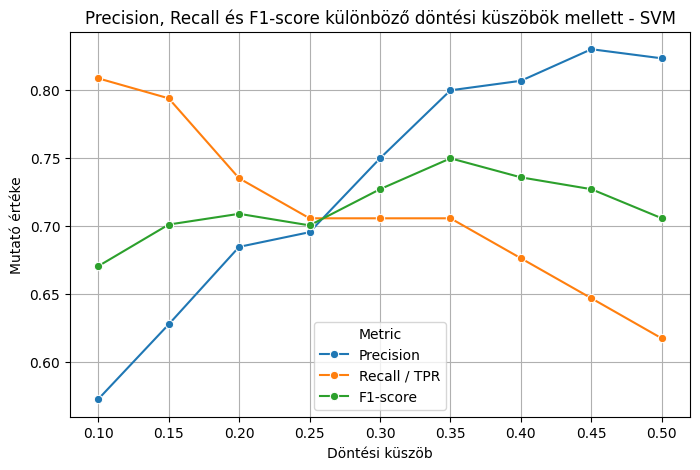

In [24]:
thresholds_to_try = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

svm_threshold_results = []
svm_confusion_matrices = {}

for threshold in thresholds_to_try:
    y_pred_threshold_svm = (y_test_proba_svm >= threshold).astype(int)
    
    cm_threshold_svm = confusion_matrix(y_test, y_pred_threshold_svm)
    tn_t, fp_t, fn_t, tp_t = cm_threshold_svm.ravel()
    
    svm_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold_svm),
        "Precision": precision_score(y_test, y_pred_threshold_svm, zero_division=0),
        "Recall / TPR": recall_score(y_test, y_pred_threshold_svm, zero_division=0),
        "Specificity / TNR": tn_t / (tn_t + fp_t) if (tn_t + fp_t) != 0 else 0,
        "FPR": fp_t / (fp_t + tn_t) if (fp_t + tn_t) != 0 else 0,
        "F1-score": f1_score(y_test, y_pred_threshold_svm, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_test_proba_svm),
        "TP": tp_t,
        "FP": fp_t,
        "FN": fn_t,
        "TN": tn_t
    })
    
    svm_confusion_matrices[threshold] = cm_threshold_svm

svm_threshold_results_df = pd.DataFrame(svm_threshold_results)
svm_threshold_results_df = svm_threshold_results_df.round(4)

display(svm_threshold_results_df)

svm_threshold_plot_df = svm_threshold_results_df.melt(
    id_vars="Threshold",
    value_vars=["Precision", "Recall / TPR", "F1-score"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=svm_threshold_plot_df,
    x="Threshold",
    y="Value",
    hue="Metric",
    marker="o"
)

plt.title("Precision, Recall és F1-score különböző döntési küszöbök mellett - SVM")
plt.xlabel("Döntési küszöb")
plt.ylabel("Mutató értéke")
plt.grid(True)
plt.show()

### 16. Végső döntési küszöb kiválasztása

A threshold vizsgálat alapján a végső SVM modellhez a **0.35-ös döntési küszöböt** választottuk.

Prediktív karbantartási feladatban a recall kiemelten fontos, mert a nem jelzett valódi meghibásodások üzleti és működési kockázatot jelenthetnek. Ugyanakkor nem célszerű kizárólag a recall maximalizálása alapján dönteni, mert az alacsonyabb küszöbök jelentősen növelhetik a téves pozitív riasztások számát.

A 0.35-ös threshold jó kompromisszumot adott a precision és recall között. Az alapértelmezett 0.50-es küszöbhöz képest a recall **0.6176-ról 0.7059-re** nőtt, vagyis a modell több valódi meghibásodást ismert fel. Ezzel párhuzamosan az FN érték **26-ról 20-ra** csökkent.

A precision ugyan kis mértékben csökkent, **0.8235-ről 0.8000-re**, de továbbra is magas maradt. A téves pozitív jelzések száma **9-ről 12-re** nőtt, ami mérsékelt növekedésnek tekinthető. Az F1-score a vizsgált küszöbök közül ennél az értéknél volt a legmagasabb, **0.7500**.

Ezért a 0.35-ös döntési küszöböt választottuk, mert jelentősen javította a meghibásodások felismerési arányát, miközben a téves riasztások száma továbbra is alacsony maradt.

In [26]:
selected_svm_threshold = 0.35

y_test_pred_svm_final = (y_test_proba_svm >= selected_svm_threshold).astype(int)

cm_svm_final = confusion_matrix(y_test, y_test_pred_svm_final)

tn_svm_final, fp_svm_final, fn_svm_final, tp_svm_final = cm_svm_final.ravel()

confusion_matrix_svm_final_df = pd.DataFrame(
    cm_svm_final,
    index=["Valós 0 - nincs meghibásodás", "Valós 1 - meghibásodás"],
    columns=["Prediktált 0 - nincs meghibásodás", "Prediktált 1 - meghibásodás"]
)

display(confusion_matrix_svm_final_df)

svm_final_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall / TPR",
        "Specificity / TNR",
        "FPR",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_score(y_test, y_test_pred_svm_final),
        precision_score(y_test, y_test_pred_svm_final, zero_division=0),
        recall_score(y_test, y_test_pred_svm_final, zero_division=0),
        tn_svm_final / (tn_svm_final + fp_svm_final) if (tn_svm_final + fp_svm_final) != 0 else 0,
        fp_svm_final / (fp_svm_final + tn_svm_final) if (fp_svm_final + tn_svm_final) != 0 else 0,
        f1_score(y_test, y_test_pred_svm_final, zero_division=0),
        roc_auc_score(y_test, y_test_proba_svm)
    ]
})

svm_final_metrics_df["Value"] = svm_final_metrics_df["Value"].round(4)

display(svm_final_metrics_df)

svm_threshold_results_df.to_csv(
    "svm_threshold_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)




,Prediktált 0 - nincs meghibásodás,Prediktált 1 - meghibásodás
Valós 0 - nincs meghibásodás,1920,12
Valós 1 - meghibásodás,20,48


,Metric,Value
0,Accuracy,0.9840
1,Precision,0.8000
2,Recall / TPR,0.7059
3,Specificity / TNR,0.9938
4,FPR,0.0062
5,F1-score,0.7500
6,ROC-AUC,0.9734


## 17. Összegzés és következtetések

Az SVM modell elkészítése során egy strukturált gépi tanulási folyamatot követtünk. A cél az volt, hogy a prediktív karbantartási adatok alapján olyan klasszifikációs modellt építsünk, amely képes előre jelezni, hogy egy adott gépállapot meghibásodáshoz vezet-e vagy sem.

Első lépésként bemutattuk, hogy az SVM miért releváns ehhez a feladathoz. A Support Vector Machine egy felügyelt tanulási algoritmus, amely klasszifikációs problémákra jól alkalmazható. Az SVM célja, hogy olyan döntési határt találjon az osztályok között, amely a lehető legnagyobb margint biztosítja. Ez azt jelenti, hogy a modell nemcsak elválasztani próbálja a két osztályt, hanem olyan határt keres, amely minél távolabb van a kritikus tanítópontoktól. Ezeket a kritikus pontokat nevezzük support vectoroknak.

A prediktív karbantartási probléma bináris klasszifikációs feladatként értelmezhető, ahol a célváltozó azt jelzi, hogy történt-e meghibásodás vagy sem. Emiatt az SVM megfelelő modellválasztás lehet, különösen azért, mert kernel segítségével nemlineáris döntési határokat is képes tanulni. Ez fontos lehet olyan adatoknál, ahol a meghibásodás nem egyetlen változó egyszerű hatásából, hanem több változó összetettebb kapcsolatából következik.

Ezután beolvastuk a korábban megtisztított `train.csv` és `test.csv` fájlokat, majd különválasztottuk a magyarázó változókat és a célváltozót. Ellenőriztük az osztályeloszlást is, mivel prediktív karbantartási feladatoknál gyakran előfordul, hogy a meghibásodásos esetek ritkábbak, mint a normál működéshez tartozó megfigyelések. Ez azért fontos, mert osztályegyensúlytalanság esetén az accuracy önmagában félrevezető lehet.

A modellspecifikus előfeldolgozás során meghatároztuk, hogy mely változókat szükséges skálázni. Az SVM különösen érzékeny a változók skálájára, mivel a modell a pontok közötti távolságokra, a marginra és a döntési határra épül. Ezért a folytonos numerikus változókat `StandardScaler` segítségével standardizáltuk. A bináris / dummy változókat változatlanul továbbengedtük, mivel ezek már 0/1 formában szerepeltek az adathalmazban.

Ezt követően létrehoztunk egy pipeline-t, amely egy folyamatba szervezte az előfeldolgozást és az SVM modellt. A pipeline használata azért volt fontos, mert így a keresztvalidáció és a későbbi tesztelés során az előfeldolgozás konzisztensen, kontrollált módon történt. Ez csökkenti az adatszivárgás kockázatát, mivel az előfeldolgozási lépések mindig a megfelelő tanító adatrészen illeszkednek.

Az SVM modell esetében hiperparaméter-keresést alkalmaztunk `GridSearchCV` segítségével. Erre azért volt szükség, mert az SVM teljesítménye jelentősen függhet a választott kernel, `C`, `gamma` és `class_weight` beállításoktól. A hiperparaméter-keresés során több lehetséges modellkonfigurációt próbáltunk ki, és ezeket 5-fold stratifikált keresztvalidációval értékeltük.

A modellválasztás alapja az F1-score volt, mivel ez egyszerre veszi figyelembe a precision és recall értékeket. Ez különösen fontos osztályegyensúlytalanság esetén, mert az accuracy önmagában nem mutatja meg megfelelően, hogy a modell mennyire ismeri fel a ritkább, de üzletileg fontos meghibásodásos eseteket.

A GridSearchCV eredményei alapján a legjobb konfiguráció az RBF kernelű SVM modell lett, `C=10`, `gamma="scale"` és `class_weight=None` beállításokkal. Az RBF kernel kiválasztása arra utal, hogy az adatokban lehetnek nemlineáris mintázatok, amelyeket egy egyszerű lineáris döntési határ kevésbé tudna jól kezelni. A `C=10` érték azt mutatja, hogy a modell viszonylag szigorúbb hibabüntetés mellett teljesített a legjobban.

A legjobb modell kiválasztása után a modellt a független teszthalmazon értékeltük. A teszthalmazt korábban nem használtuk sem tanításra, sem hiperparaméter-választásra, ezért alkalmas volt arra, hogy objektív képet adjon a modell új adatokon várható teljesítményéről.

A teszteredmények alapján az SVM modell erős teljesítményt mutatott. Az accuracy értéke magas lett, azonban az értékelés során nem csak ezt vettük figyelembe. A precision, recall, F1-score és ROC-AUC mutatók alapján is megvizsgáltuk a modell teljesítményét. A modell magas precision értéket ért el, vagyis a meghibásodásként jelzett esetek nagy része valóban meghibásodás volt. A recall értéke is jelentősen jobb lett, mint a korábbi egyszerűbb modellnél, vagyis az SVM a valódi meghibásodások nagyobb részét felismerte.

A ROC görbe és az AUC érték alapján megállapítható volt, hogy az SVM modell nagyon jó osztályszétválasztó képességgel rendelkezik. A magas ROC-AUC érték azt jelzi, hogy a modell valószínűségi szinten is jól elkülöníti a meghibásodásos és nem meghibásodásos eseteket.

Mivel az SVM modellt `probability=True` beállítással tanítottuk, lehetőségünk volt döntési küszöb vizsgálatot is végezni. Ez azt jelentette, hogy nem csak az alapértelmezett 0.5-ös threshold mellett értékeltük a modellt, hanem több alacsonyabb küszöböt is kipróbáltunk. A cél az volt, hogy megvizsgáljuk, javítható-e a recall és az F1-score úgy, hogy közben a precision ne romoljon túl nagy mértékben.

A threshold vizsgálat alapján a 0.35-ös döntési küszöb bizonyult a legjobb választásnak. Ennél a thresholdnál a modell F1-score értéke volt a legmagasabb, miközben a recall is javult az alapértelmezett 0.5-ös küszöbhöz képest. Ez azt jelenti, hogy a modell több valódi meghibásodást ismert fel, miközben a téves pozitív riasztások száma csak mérsékelten nőtt.

Prediktív karbantartási szempontból ez jó kompromisszumot jelent. A nem jelzett valódi meghibásodások komolyabb üzleti és működési kockázatot jelenthetnek, mint néhány többlet téves riasztás kezelése. Emiatt a 0.35-ös threshold választása szakmailag indokolható.

Összességében az SVM modell erős eredményt adott a prediktív karbantartási feladaton. A hiperparaméter-keresésnek köszönhetően sikerült olyan SVM konfigurációt választani, amely jól teljesített a keresztvalidáció során és a független teszthalmazon is. Az RBF kernel lehetővé tette a nemlineáris mintázatok kezelését, a threshold vizsgálat pedig segített a döntési küszöböt a feladat üzleti logikájához igazítani.

A modell előnye, hogy jó osztályszétválasztó képességet, magas precisiont, javított recallt és erős F1-score-t ért el. Hátránya, hogy az SVM kevésbé könnyen értelmezhető, mint például a logisztikus regresszió, különösen RBF kernel esetén. Emellett a hiperparaméter-keresés számításigényesebb lehet.

A későbbi modell-összehasonlítás során érdemes az SVM eredményeit összevetni a többi modellel, például döntési fával, Random Foresttel, Gradient Boostinggal, XGBoosttal és Naive Bayes modellel. Az eddigi eredmények alapján az SVM erős jelöltnek tekinthető a végső modellek között.